In [ ]:
import numpy as np      ## ⭐ 学习点：import 导入。as 是给库起别名，之后用 np 代替 numpy
import pandas as pd   ## ⭐ 学习点：pd 是 Pandas 的别名，表格处理库
import matplotlib.pyplot as plt  ## ⭐ 学习点：plt 是画图模块的别名

In [ ]:
def make_tensile_data(name, E, yield_str, tensile_str, fracture, n_points=500):
    """
    模拟万能试验机生成的拉伸数据
    参数：
        name: 材料名字（字符串）
        E: 弹性模量，单位 GPa
        yield_str: 屈服强度，单位 MPa
        tensile_str: 抗拉强度，单位 MPa
        fracture: 断裂应变，单位 mm/mm（比如0.25表示25%）
        n_points: 生成多少个数据点
    """
    
    E_mpa = E * 1000  # GPa 转 MPa
    
    ## ⭐ 学习点 1：np.linspace(start, stop, num)
    ## 作用：在 0 到 fracture 之间，均匀生成 n_points 个数
    ## 类比：就像把标距 50mm 分成 500 个等间距采样点
    strain = np.linspace(0, fracture, n_points)
    
    # 计算屈服应变（胡克定律）
    yield_strain = yield_str / E_mpa
    
    # 假设峰值出现在断裂前的 65% 位置
    peak_strain = fracture * 0.65
    
    ## ⭐ 学习点 2：np.zeros(shape)
    ## 作用：创建一个长度为 n_points、里面全是 0 的数组
    ## 类比：先画一张空白表格，500行，准备往里填数据
    stress = np.zeros(n_points)
    
    ## ⭐ 学习点 3：enumerate(可迭代对象)
    ## 作用：同时拿到"索引 i"和"数值 eps"
    ## 类比：你检查500个零件，enumerate 就是告诉你"第几个零件"和"这个零件的值"
    for i, eps in enumerate(strain):
        
        if eps <= yield_strain:
            # 弹性段
            stress[i] = E_mpa * eps
            
        elif eps <= peak_strain:
            # 强化段
            ratio = (eps - yield_strain) / (peak_strain - yield_strain)
            stress[i] = yield_str + (tensile_str - yield_str) * (ratio ** 0.5)
            
        else:
            # 颈缩段
            ratio = (eps - peak_strain) / (fracture - peak_strain)
            stress[i] = tensile_str * (1 - 0.35 * ratio)
    
    ## ⭐ 学习点 4：np.random.normal(loc, scale, size)
    ## 作用：生成正态分布的随机噪声
    ## loc=0 表示平均值为0，scale 是标准差（这里设为抗拉强度的1.5%）
    ## 类比：模拟试验机传感器的信号抖动
    noise = np.random.normal(0, tensile_str * 0.015, n_points)
    stress = stress + noise
    
    # 试样参数
    diameter = 10          # mm
    gauge_length = 50      # mm
    area = 3.14159 * (diameter/2)**2  # 横截面积
    
    # 换算成试验机原始数据
    force_kn = stress * area / 1000
    displacement_mm = strain * gauge_length
    
    ## ⭐ 学习点 5：pd.DataFrame(data_dict)
    ## 作用：把字典转换成表格
    ## 字典的"键"变成列名，"值"变成列数据
    ## 类比：Excel 里新建工作表，第一行是表头，下面是数据
    df = pd.DataFrame({
        '位移_mm': displacement_mm,
        '力_kN': force_kn,
        '应变': strain,
        '应力_MPa': stress,
        '材料': name
    })
    
    return df

✅ 已保存：Q235_tensile.csv
✅ 已保存：45钢_tensile.csv
✅ 已保存：6061铝_tensile.csv
✅ 已保存：304不锈钢_tensile.csv


C:\Users\15821\AppData\Local\Temp\ipykernel_16344\1408744309.py:36: UserWarning: Glyph 38050 (\N{CJK UNIFIED IDEOGRAPH-94A2}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\15821\AppData\Local\Temp\ipykernel_16344\1408744309.py:36: UserWarning: Glyph 38109 (\N{CJK UNIFIED IDEOGRAPH-94DD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\15821\AppData\Local\Temp\ipykernel_16344\1408744309.py:36: UserWarning: Glyph 19981 (\N{CJK UNIFIED IDEOGRAPH-4E0D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\15821\AppData\Local\Temp\ipykernel_16344\1408744309.py:36: UserWarning: Glyph 38152 (\N{CJK UNIFIED IDEOGRAPH-9508}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\15821\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 38050 (\N{CJK UNIFIED IDEOGRAPH-94A2}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\15821\AppData\Roaming\Python\Python314\

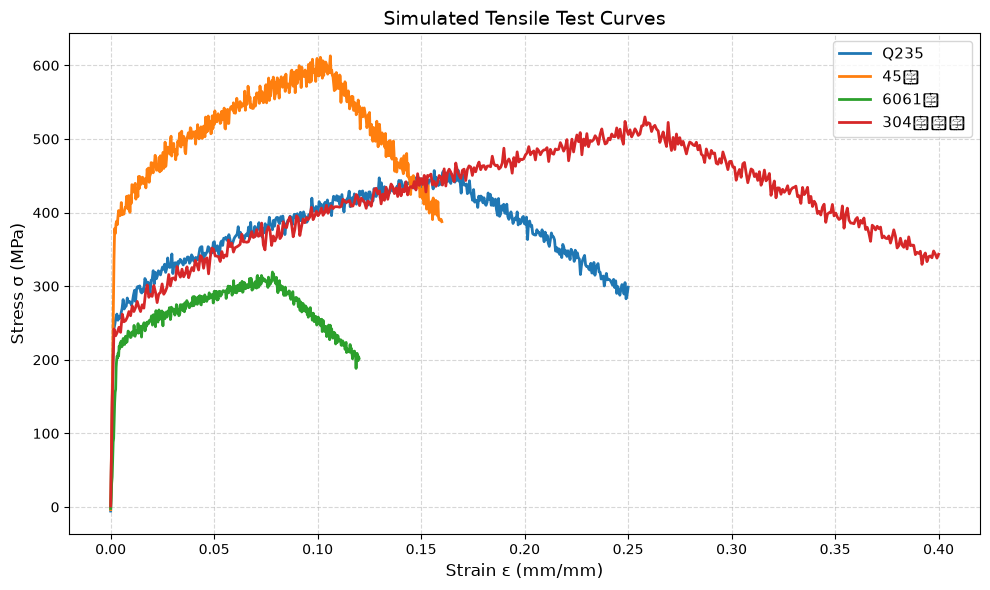


🎉 完成！请检查左侧文件栏，应该出现了3个CSV文件。


In [ ]:
## ⭐ 学习点 6：字典（dict）
## 作用：用大括号 {} 存"键值对"，通过名字找参数
## 类比：像材料数据库，输入"Q235"就能查到它的E、屈服强度等
materials = {
    'Q235':   {'E': 200, 'yield': 235, 'tensile': 370, 'fracture': 0.25},
    '45钢':   {'E': 210, 'yield': 355, 'tensile': 600, 'fracture': 0.16},
    '6061铝': {'E': 70,  'yield': 276, 'tensile': 310, 'fracture': 0.12}
}

## ⭐ 学习点 7：plt.figure(figsize=(宽, 高))
## 作用：创建一张新画布，figsize 控制尺寸（单位：英寸）
plt.figure(figsize=(10, 6))

## ⭐ 学习点 8：dict.items()
## 作用：遍历字典，每次返回一对 (键, 值)
## 这里 name 是 'Q235'，param 是 {'E':200, ...} 这个小字典
for name, param in materials.items():
    
    # 调用上面的函数生成数据
    df = make_tensile_data(
        name=name,
        E=param['E'],
        yield_str=param['yield'],
        tensile_str=param['tensile'],
        fracture=param['fracture']
    )
    
    ## ⭐ 学习点 9：f-string 格式化字符串
    ## 作用：f'{变量}' 会把变量值嵌入字符串
    ## 这里 {name} 会被替换成 'Q235'、'45钢' 等
    filename = f'{name}_tensile.csv'
    
    ## ⭐ 学习点 10：df.to_csv(path, index=False, encoding='utf-8-sig')
    ## 作用：把表格保存为 CSV 文件
    ## index=False 表示不保存行号（0,1,2...）
    ## encoding='utf-8-sig' 让 Excel 打开不乱码
    df.to_csv(filename, index=False, encoding='utf-8-sig')
    print(f"已保存：{filename}")
    
    ## ⭐ 学习点 11：plt.plot(x, y, label=..., linewidth=...)
    ## 作用：画折线图
    ## x=df['应变'] 表示取"应变"这一列作为横坐标
    ## label 是图例里显示的名字
    plt.plot(df['应变'], df['应力_MPa'], label=name, linewidth=2)

## ⭐ 学习点 12：plt 系列美化函数
plt.xlabel('Strain ε (mm/mm)', fontsize=12)   # x轴标签
plt.ylabel('Stress σ (MPa)', fontsize=12)      # y轴标签
plt.title('Simulated Tensile Test Curves', fontsize=14)  # 标题
plt.legend(fontsize=11)                        # 显示图例
plt.grid(True, linestyle='--', alpha=0.5)      # 显示网格线
plt.tight_layout()                             # 自动调整边距，防止标签被截断
plt.show()                                     # 把图画出来

print("\n🎉 完成！检查左侧文件栏，应该出现了3个CSV文件。")